<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Regresion_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Regresion

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    max_error
)
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

Carga del dataset

In [3]:
print(" REGRESION")
df_reg = pd.read_csv('RT_IOT2022_regresion.csv')

if 'Attack Type' in df_reg.columns:
  print("Esta la variable, QUITAR")
else:
  print("No esta la variable, CONTINUAR")

df_reg.shape

 REGRESION
No esta la variable, CONTINUAR


(123117, 79)

Limpieza manual

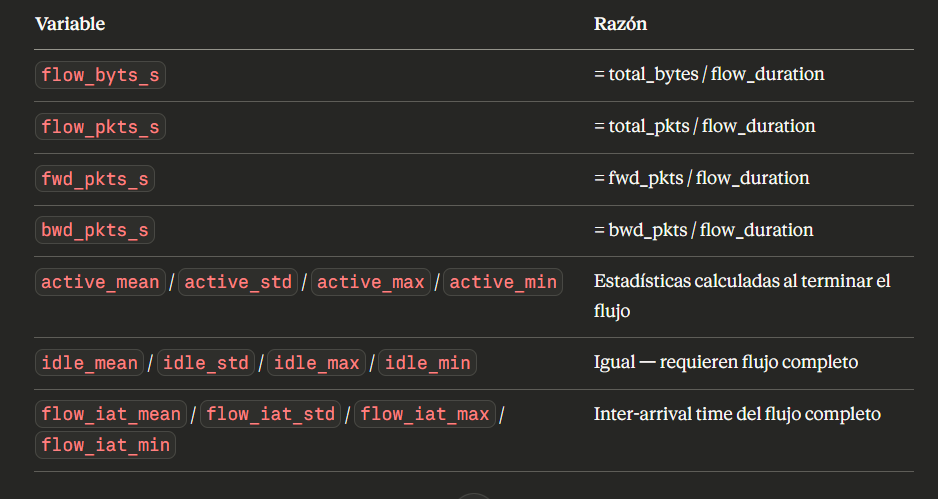


In [4]:
columnas_eliminar = {
    # Tasas que dividen entre flow_duration
    'fwd_pkts_per_sec', 'payload_bytes_per_second',
    'fwd_bulk_rate', 'bwd_bulk_rate',

    # Estadísticas post-facto de flujo completo
    'flow_iat.min', 'flow_iat.avg', 'flow_iat.std',
    'active.min', 'active.max', 'active.tot', 'active.avg', 'active.std',
    'idle.min', 'idle.std',

    # Totales acumulativos al cierre
    'bwd_iat.tot',
    'fwd_pkts_tot', 'fwd_data_pkts_tot',
    'fwd_pkts_payload.tot',
    'fwd_header_size_tot', 'bwd_header_size_tot',
    'bwd_pkts_tot',

    # Leakage estructural confirmado
    'fwd_iat.max', 'bwd_iat.max', 'fwd_iat.min',

    # Variable constante
    'bwd_URG_flag_count',

    #Terminacion tot, todas estas con terminacion tot representan valores de acumulaciones
    'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_pkts_payload.tot', 'fwd_data_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot', 'fwd_pkts_payload.tot', 'bwd_iat.tot',

    # Leakage estructural — acotadas por flow_duration
    'fwd_iat.std', 'fwd_iat.avg',
    'bwd_iat.std', 'bwd_iat.avg',  # verificar estas también

    'fwd_pkts_payload.max', 'fwd_pkts_payload.min', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std',

    'bwd_pkts_payload.max', 'bwd_pkts_payload.min', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std',

    'flow_pkts_payload.max', 'flow_pkts_payload.min', 'flow_pkts_payload.avg', 'flow_pkts_payload.std'
}

df_reg = df_reg.drop(columns=columnas_eliminar, errors='ignore')

#df_reg.to_csv('rt_iot2022_sin_leakage_clasificacion.csv', index=False)

df_reg

,down_up_ratio,fwd_header_size_min,fwd_header_size_max,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,...,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl,flow_duration
0,-0.885605,2.285145,2.676563,1.788560,2.292864,-0.243374,2.212145,0.465785,0.670275,0.433858,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,32.011598
1,-0.885605,2.285145,2.676563,1.788560,2.292864,-0.243374,2.212145,0.465785,0.670275,0.433858,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.883584
2,-0.885605,2.285145,2.676563,1.788560,2.292864,-0.243374,2.212145,0.465785,0.670275,0.433858,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,32.124053
3,-0.885605,2.285145,2.676563,1.788560,2.292864,-0.243374,2.212145,0.465785,0.670275,0.433858,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.961063
4,-0.885605,2.285145,2.676563,1.788560,2.292864,-0.243374,2.212145,0.465785,0.670275,0.433858,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.902362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,0.430725,0.041251,-0.089430,0.288099,0.166625,1.861839,-2.004950,0.465785,0.164153,-0.065525,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006
123113,0.430725,0.041251,-0.089430,0.288099,0.166625,1.861839,-2.004950,0.465785,0.164153,-0.065525,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000007
123114,0.430725,0.041251,-0.089430,0.288099,0.166625,1.861839,-2.004950,0.465785,0.164153,-0.065525,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006
123115,0.430725,0.041251,-0.089430,0.288099,0.166625,1.861839,-2.004950,0.465785,0.164153,-0.065525,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006


Variable objetivo

In [5]:
df_reg = df_reg[df_reg['flow_duration'] >= 0] #Se eliminan valores negativos

Target = 'flow_duration'

#Variable objetivo
y = df_reg[Target]

#Caracteristicas
X = df_reg.drop(columns=[Target])

print(f"Variable objetivo: {Target}")
print(f"Cantidad de timepos\n{df_reg[Target].value_counts()}")
print('idle.min' in X.columns)

Variable objetivo: flow_duration
Cantidad de timepos
flow_duration
0.000004    33623
0.000001    26640
0.000000    15981
0.000005    12658
0.000002     7270
            ...  
0.671607        1
0.030744        1
0.900523        1
0.028183        1
0.866314        1
Name: count, Length: 16380, dtype: int64
False


Division de datos

In [6]:
y_log = np.log1p(y)
#Distribución muy sesgada (skewed)
#flow_duration tiene valores que van desde fracciones de segundo hasta cientos o miles de segundos. La mayoría de flujos duran poco, pero hay algunos extremadamente largos — esto genera una distribución con cola muy larga a la derecha.

#Diferencias de magnitud enormes
#Sin log, un flujo de 0.001s y uno de 10,000s coexisten. El modelo sin transformación tendería a optimizarse para los valores grandes e ignorar los pequeños, porque el error absoluto en valores grandes domina la función de pérdida.

#log1p
#Comprime los valores grandes, expande los pequeños
#Convierte la distribución sesgada en algo más normal y simétrico
#El modelo aprende proporciones en lugar de diferencias absolutas

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

Revision de variables con relacion matematica con la variable objetivo

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('RT_IOT2022_regresion.csv')

# ¿fwd_iat.max siempre es <= flow_duration?
violaciones = (df['fwd_iat.max'] > df['flow_duration']).sum()
print(f'Violaciones: {violaciones} de {len(df)}')

# ¿Qué tan cerca están?
ratio = df['fwd_iat.max'] / df['flow_duration'].replace(0, np.nan)
print(ratio.describe())

Violaciones: 0 de 123117
count    107136.000000
mean     -75022.208098
std       67998.116711
min     -186537.732000
25%      -93268.866000
50%      -46634.433000
75%      -37307.546400
max           0.107648
dtype: float64


In [8]:
violaciones_std = (df['fwd_iat.std'] > df['flow_duration']).sum()
print(f'Violaciones fwd_iat.std: {violaciones_std}')

violaciones_avg = (df['fwd_iat.avg'] > df['flow_duration']).sum()
print(f'Violaciones fwd_iat.avg: {violaciones_avg}')

print(df['fwd_iat.std'].describe())
print(df['fwd_iat.avg'].describe())

Violaciones fwd_iat.std: 0
Violaciones fwd_iat.avg: 0
count    1.231170e+05
mean    -3.969151e-10
std      1.000004e+00
min     -1.802164e-01
25%     -1.802164e-01
50%     -1.802164e-01
75%     -1.802164e-01
max      6.606309e+01
Name: fwd_iat.std, dtype: float64
count    1.231170e+05
mean    -3.567744e-10
std      1.000004e+00
min     -1.252317e-01
25%     -1.252317e-01
50%     -1.252317e-01
75%     -1.252317e-01
max      1.582904e+02
Name: fwd_iat.avg, dtype: float64


In [9]:
# Ejecutar esto para decidir próximas eliminaciones
variables_verificar = [
    'fwd_iat.min', 'bwd_iat.min',
    'fwd_PSH_flag_count', 'bwd_PSH_flag_count',
    'flow_ACK_flag_count', 'flow_FIN_flag_count',
    'fwd_subflow_pkts', 'bwd_subflow_pkts'
]

for col in variables_verificar:
    if col in df.columns:
        violaciones = (df[col] > df['flow_duration']).sum()
        negativos = (df[col] < 0).sum()
        print(f'{col:<25} violaciones: {violaciones:>6} | negativos: {negativos:>6}')

fwd_iat.min               violaciones:      0 | negativos: 121742
bwd_iat.min               violaciones:   3452 | negativos: 118595
fwd_PSH_flag_count        violaciones:   2811 | negativos: 110612
bwd_PSH_flag_count        violaciones:    309 | negativos: 113159
flow_ACK_flag_count       violaciones:    639 | negativos: 112584
flow_FIN_flag_count       violaciones:   6568 | negativos: 115053
fwd_subflow_pkts          violaciones:  11143 | negativos: 105840
bwd_subflow_pkts          violaciones:   7946 | negativos: 106128


In [22]:
# Rangos de duración para evaluación segmentada
# Basados en la distribución real del dataset
RANGOS = {
    'Muy corto  (< 0.001s)' : (0,       0.001),
    'Corto      (0.001–1s)' : (0.001,   1.0),
    'Medio      (1s–10s)  ' : (1.0,     10.0),
    'Largo      (10s–60s) ' : (10.0,    60.0),
    'Muy largo  (> 60s)   ' : (60.0,    np.inf),
}

y_test_real = np.expm1(y_test_log)

# Conteo por rango en test
print('Distribución del set de test por rango:')
print(f"{'Rango':<30} {'N':>8} {'%':>8}")
print('-' * 50)
for nombre, (lo, hi) in RANGOS.items():
    mask = (y_test_real >= lo) & (y_test_real < hi)
    n = mask.sum()
    pct = 100 * n / len(y_test_real)
    print(f'{nombre:<30} {n:>8,} {pct:>7.1f}%')
print(f"{'TOTAL':<30} {len(y_test_real):>8,} {'100.0%':>8}")

Distribución del set de test por rango:
Rango                                 N        %
--------------------------------------------------
Muy corto  (< 0.001s)            21,259    86.3%
Corto      (0.001–1s)             1,824     7.4%
Medio      (1s–10s)                 415     1.7%
Largo      (10s–60s)                691     2.8%
Muy largo  (> 60s)                  435     1.8%
TOTAL                            24,624   100.0%


Modelo de regresion continuo

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- 0. ESCALAMIENTO (Requisito indispensable para Redes Neuronales) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. MODELO ---
modelo_reg_mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True
)

# Nota: Entrenamos con los datos ESCALADOS
modelo_reg_mlp.fit(X_train_scaled, y_train_log)

# --- 2. PREDECIR ---
# Nota: Predecimos con los datos ESCALADOS
pred_log_mlp = modelo_reg_mlp.predict(X_test_scaled)

# Mantenemos tus recortes de seguridad matemática intactos
predicciones_tiempo_mlp = np.expm1(np.clip(pred_log_mlp, -np.inf, 10))
predicciones_tiempo_mlp = np.clip(predicciones_tiempo_mlp, 0, None)
y_test_original_mlp = np.expm1(y_test_log)

# --- 3. MÉTRICAS EN ESCALA LOG (comparando log vs log) ---
mae_log_mlp  = mean_absolute_error(y_test_log, pred_log_mlp)
mse_log_mlp  = mean_squared_error(y_test_log, pred_log_mlp)
rmse_log_mlp = np.sqrt(mse_log_mlp)
r2_log_mlp   = r2_score(y_test_log, pred_log_mlp)

# --- 4. MÉTRICAS EN ESCALA REAL (comparando segundos vs segundos) ---
mae_real_mlp  = mean_absolute_error(y_test_original_mlp, predicciones_tiempo_mlp)
mse_real_mlp  = mean_squared_error(y_test_original_mlp, predicciones_tiempo_mlp)
rmse_real_mlp = np.sqrt(mse_real_mlp)
r2_real_mlp   = r2_score(y_test_original_mlp, predicciones_tiempo_mlp)

# --- 5. RESULTADOS ---
print("\n  RESULTADOS DE EVALUACIÓN RED NEURONAL (MLP)")
print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  (Error Absoluto Medio):    {mae_log_mlp:.6f}")
print(f"  MSE  (Error Cuadrático Medio):  {mse_log_mlp:.6f}")
print(f"  RMSE (Raíz del MSE):            {rmse_log_mlp:.6f}")
print(f"  R²   (Coeficiente de det.):     {r2_log_mlp:.6f}")

print(f"\n  — Escala real (segundos) —")
print(f"  MAE  (Error Absoluto Medio):    {mae_real_mlp:.6f}")
print(f"  MSE  (Error Cuadrático Medio):  {mse_real_mlp:.6f}")
print(f"  RMSE (Raíz del MSE):            {rmse_real_mlp:.6f}")
print(f"  R²   (Coeficiente de det.):     {r2_real_mlp:.6f}")


  RESULTADOS DE EVALUACIÓN RED NEURONAL (MLP)

  — Escala logarítmica (log1p) —
  MAE  (Error Absoluto Medio):    0.045178
  MSE  (Error Cuadrático Medio):  0.034456
  RMSE (Raíz del MSE):            0.185623
  R²   (Coeficiente de det.):     0.948015

  — Escala real (segundos) —
  MAE  (Error Absoluto Medio):    1.083339
  MSE  (Error Cuadrático Medio):  114.790126
  RMSE (Raíz del MSE):            10.714015
  R²   (Coeficiente de det.):     0.628067


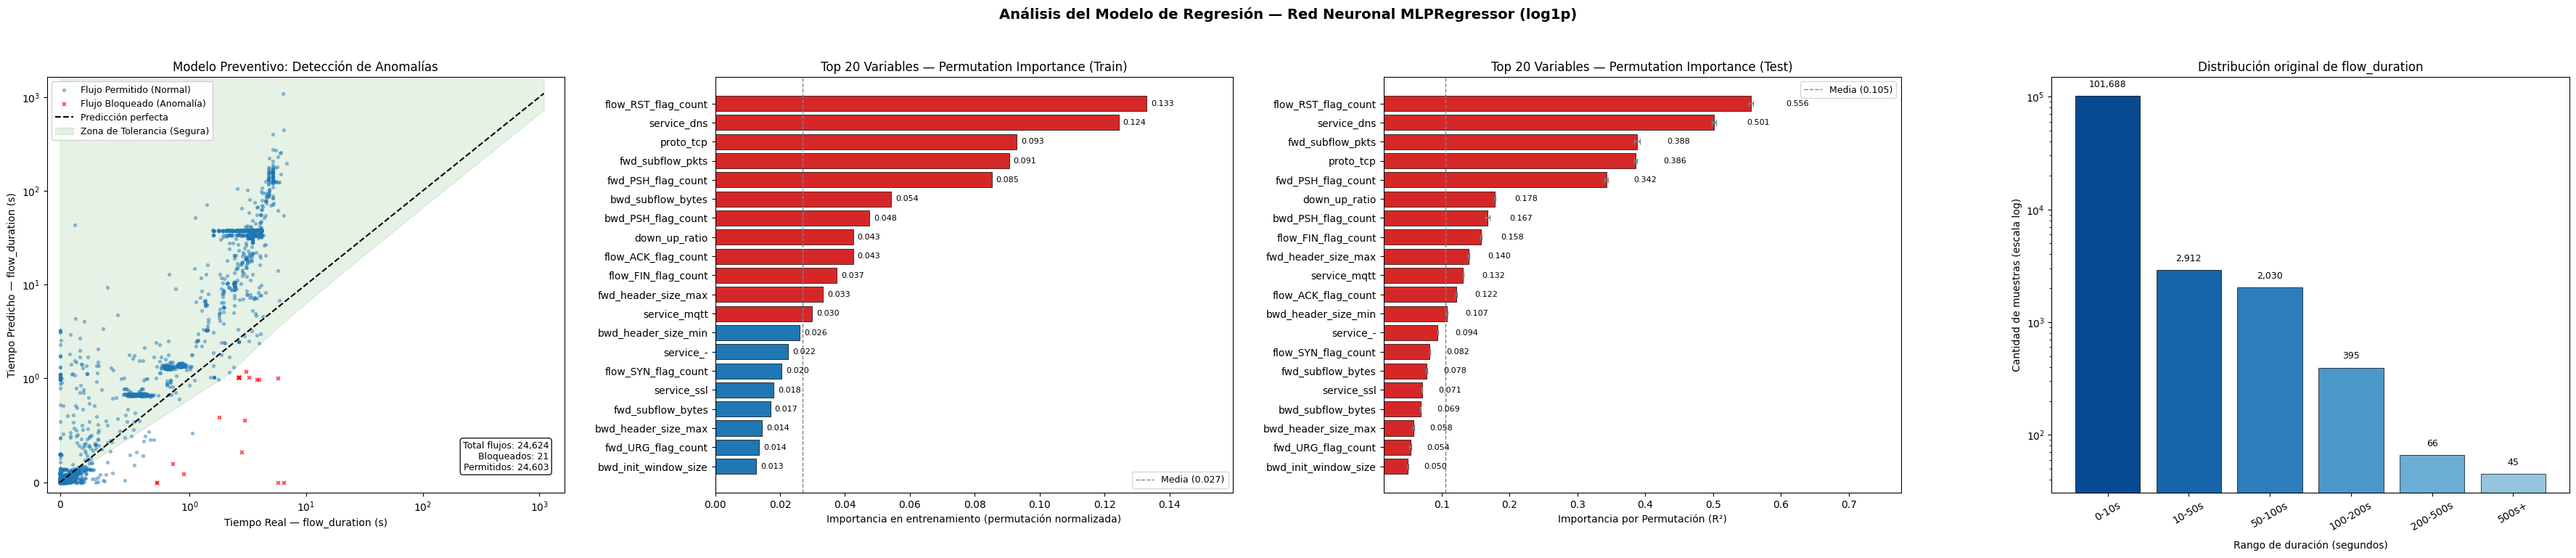

In [11]:
from scipy.stats import gaussian_kde
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axs = plt.subplots(1, 4, figsize=(36, 8))
fig.suptitle('Análisis del Modelo de Regresión — Red Neuronal MLPRegressor (log1p)', fontsize=14, fontweight='bold')

# --- CONFIGURACIÓN DE LA REGLA PREVENTIVA ---
margen_tolerancia = 1.5
segundos_de_gracia = 0.5

# Calculamos qué flujos habrían sido bloqueados por exceder el tiempo predicho
tiempo_max_permitido = (predicciones_tiempo_mlp * margen_tolerancia) + segundos_de_gracia
mask_bloqueados = y_test_log > tiempo_max_permitido
mask_normales = ~mask_bloqueados

# --- GRÁFICA 1: Regresión Preventiva ---
# Separamos los datos para graficarlos con colores distintos
x_normales = y_test_log[mask_normales]
y_normales = predicciones_tiempo_mlp[mask_normales]

x_bloqueados = y_test_log[mask_bloqueados]
y_bloqueados = predicciones_tiempo_mlp[mask_bloqueados]

# 1. Graficamos los flujos normales (Zona Segura)
axs[0].scatter(x_normales, y_normales, color='#1f77b4', alpha=0.4, s=8, label='Flujo Permitido (Normal)')

# 2. Graficamos los flujos bloqueados (Anomalías / Puntos Voladores)
axs[0].scatter(x_bloqueados, y_bloqueados, color='red', alpha=0.7, s=12, marker='x', label='Flujo Bloqueado (Anomalía)')

# 3. Dibujamos la línea de Predicción Perfecta
min_val = min(y_test_log.min(), predicciones_tiempo_mlp.min())
max_val = max(y_test_log.max(), predicciones_tiempo_mlp.max())
axs[0].plot([min_val, max_val], [min_val, max_val], color='black', linewidth=1.5, linestyle='--', label='Predicción perfecta')

# 4. Sombreamos la "Zona Segura" (Lógica del Controlador)
# El eje X es el tiempo real, el eje Y es la predicción.
# La fórmula es: Real <= (Predicción * 1.5) + 1.0
# Despejando para sombrear en la gráfica: Predicción >= (Real - 1.0) / 1.5
x_vals_fill = np.linspace(min_val, max_val, 500)
y_vals_fill_limite = (x_vals_fill - segundos_de_gracia) / margen_tolerancia
# Evitamos valores negativos en la predicción para el sombreado
y_vals_fill_limite = np.clip(y_vals_fill_limite, 0, None)

axs[0].fill_between(x_vals_fill, y_vals_fill_limite, max_val * 2,
                    color='green', alpha=0.1, label='Zona de Tolerancia (Segura)', zorder=0)

# Configuración de los ejes (usando escala simétrica logarítmica como decidiste antes)
axs[0].set_xscale('symlog', linthresh=1.0)
axs[0].set_yscale('symlog', linthresh=1.0)

# Para que el sombreado no expanda infinitamente la gráfica
axs[0].set_xlim(-0.1, max_val * 1.5)
axs[0].set_ylim(-0.1, max_val * 1.5)

axs[0].set_xlabel('Tiempo Real — flow_duration (s)')
axs[0].set_ylabel('Tiempo Predicho — flow_duration (s)')
axs[0].set_title('Modelo Preventivo: Detección de Anomalías')

# Ajustamos la leyenda para que se vea la nueva lógica
axs[0].legend(loc='upper left', fontsize=9, framealpha=0.9)

# Cuadro de métricas
axs[0].text(0.97, 0.05,
    f'Total flujos: {len(y_test_log):,}\nBloqueados: {np.sum(mask_bloqueados):,}\nPermitidos: {np.sum(mask_normales):,}',
    transform=axs[0].transAxes, verticalalignment='bottom',
    horizontalalignment='right', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# --- Gráfica 2: Feature Importance (Permutation en Entrenamiento) ---
# CRÍTICO: Pasamos X_train_scaled en lugar de X_train
perm_fi = permutation_importance(
    modelo_reg_mlp, X_train_scaled, y_train_log,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='r2' # Cambié n_jobs a -1 para acelerarlo
)
importancias_fi = np.clip(perm_fi.importances_mean, 0, None)
importancias_fi = importancias_fi / importancias_fi.sum() if importancias_fi.sum() > 0 else importancias_fi
# Rescatamos los nombres de las columnas del X_train original (pandas)
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20

umbral_fi      = 0.001
top_indices_fi = [i for i in indices_fi[:top_n] if importancias_fi[i] > umbral_fi]
top_nombres_fi = [nombres[i] for i in top_indices_fi][::-1]
top_valores_fi = importancias_fi[top_indices_fi][::-1]
colores_fi     = ['#d62728' if v > importancias_fi.mean() else '#1f77b4' for v in top_valores_fi]

axs[1].barh(top_nombres_fi, top_valores_fi, color=colores_fi, edgecolor='black', linewidth=0.5)
axs[1].axvline(x=importancias_fi.mean(), color='gray', linestyle='--', linewidth=1,
               label=f'Media ({importancias_fi.mean():.3f})')
axs[1].set_xlim(0, top_valores_fi.max() * 1.2)
axs[1].set_xlabel('Importancia en entrenamiento (permutación normalizada)')
axs[1].set_title(f'Top {len(top_nombres_fi)} Variables — Permutation Importance (Train)')
axs[1].legend(fontsize=9)
for i, v in enumerate(top_valores_fi):
    if v > umbral_fi:
        axs[1].text(v + top_valores_fi.max() * 0.01, i, f'{v:.3f}', va='center', fontsize=8)

# --- Gráfica 3: Permutation Importance (Prueba) ---
# CRÍTICO: Pasamos X_test_scaled en lugar de X_test
perm_imp = permutation_importance(
    modelo_reg_mlp, X_test_scaled, y_test_log,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='r2' # n_jobs=-1 para paralelizar
)
importancias_perm = perm_imp.importances_mean
std_vals          = perm_imp.importances_std
indices_perm      = np.argsort(importancias_perm)[::-1]

top_nombres_perm = [nombres[i] for i in indices_perm[:top_n]][::-1]
top_valores_perm = importancias_perm[indices_perm[:top_n]][::-1]
top_std          = std_vals[indices_perm[:top_n]][::-1]
colores_perm     = ['#d62728' if v > 0 else '#aec7e8' for v in top_valores_perm]

axs[2].barh(top_nombres_perm, top_valores_perm, xerr=top_std,
            color=colores_perm, edgecolor='black', linewidth=0.5,
            error_kw=dict(ecolor='gray', capsize=3))
axs[2].axvline(x=0, color='black', linewidth=0.8, linestyle='-')
axs[2].axvline(x=importancias_perm.mean(), color='gray', linestyle='--', linewidth=1,
               label=f'Media ({importancias_perm.mean():.3f})')

min_perm = (top_valores_perm - top_std).min()
max_perm = (top_valores_perm + top_std).max()
axs[2].set_xlim(min_perm * 1.3 - 0.05, max_perm * 1.3 + 0.05)
axs[2].set_xlabel('Importancia por Permutación (R²)')
axs[2].set_title(f'Top {top_n} Variables — Permutation Importance (Test)')
axs[2].legend(fontsize=9)
for i, v in enumerate(top_valores_perm):
    offset = top_std[i] + abs(v) * 0.05 + 0.02
    if v >= 0:
        axs[2].text(v + offset, i, f'{v:.3f}', va='center', ha='left', fontsize=8)
    else:
        axs[2].text(v - offset, i, f'{v:.3f}', va='center', ha='right', fontsize=8)

# --- Gráfica 4: Distribución de flow_duration por rangos ---
# Esto asume que tienes la variable 'y' global (original sin transformar) en tu entorno
rangos    = [0, 10, 50, 100, 200, 500, float('inf')]
etiquetas = ['0-10s', '10-50s', '50-100s', '100-200s', '200-500s', '500s+']
conteo    = pd.cut(y, bins=rangos, labels=etiquetas).value_counts().sort_index()

colores_dist = plt.cm.Blues(np.linspace(0.4, 0.9, len(conteo)))[::-1]
bars = axs[3].bar(conteo.index, conteo.values, color=colores_dist, edgecolor='black', linewidth=0.5)
axs[3].set_yscale('log')
axs[3].set_xlabel('Rango de duración (segundos)', labelpad=8)
axs[3].set_ylabel('Cantidad de muestras (escala log)')
axs[3].set_title('Distribución original de flow_duration')
axs[3].tick_params(axis='x', rotation=30)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axs[3].text(bar.get_x() + bar.get_width() / 2., h * 1.15,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(pad=2.5, w_pad=3.0)
#plt.savefig('analisis_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

Aplicacion de modelo random forest

In [12]:
# --- MODELO ---
modelo_reg_random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_reg_random_forest.fit(X_train, y_train_log)

# --- PREDECIR ---
pred_log_rf = modelo_reg_random_forest.predict(X_test)

predicciones_tiempo_rf = np.expm1(np.clip(pred_log_rf, -np.inf, 10))
predicciones_tiempo_rf = np.clip(predicciones_tiempo_rf, 0, None)
y_test_original_rf = np.expm1(y_test_log)

# --- MÉTRICAS EN ESCALA LOG (comparando log vs log) ---
mae_log  = mean_absolute_error(y_test_log, pred_log_rf)
mse_log  = mean_squared_error(y_test_log, pred_log_rf)
rmse_log = np.sqrt(mse_log)
r2_log   = r2_score(y_test_log, pred_log_rf)

# --- MÉTRICAS EN ESCALA REAL (comparando segundos vs segundos) ---
mae_real  = mean_absolute_error(y_test_original_rf, predicciones_tiempo_rf)
mse_real  = mean_squared_error(y_test_original_rf, predicciones_tiempo_rf)
rmse_real = np.sqrt(mse_real)
r2_real   = r2_score(y_test_original_rf, predicciones_tiempo_rf)

print("\n  RESULTADOS DE EVALUACIÓN RANDOM_FOREST")
print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  (Error Absoluto Medio):    {mae_log:.6f}")
print(f"  MSE  (Error Cuadrático Medio):  {mse_log:.6f}")
print(f"  RMSE (Raíz del MSE):            {rmse_log:.6f}")
print(f"  R²   (Coeficiente de det.):     {r2_log:.6f}")
# Falta agregar esto al print:
print(f"\n  — Escala real (segundos) —")
print(f"  MAE  (Error Absoluto Medio):    {mae_real:.6f}")
print(f"  MSE  (Error Cuadrático Medio):  {mse_real:.6f}")
print(f"  RMSE (Raíz del MSE):            {rmse_real:.6f}")
print(f"  R²   (Coeficiente de det.):     {r2_real:.6f}")


  RESULTADOS DE EVALUACIÓN RANDOM_FOREST

  — Escala logarítmica (log1p) —
  MAE  (Error Absoluto Medio):    0.029631
  MSE  (Error Cuadrático Medio):  0.032457
  RMSE (Raíz del MSE):            0.180157
  R²   (Coeficiente de det.):     0.951032

  — Escala real (segundos) —
  MAE  (Error Absoluto Medio):    1.046685
  MSE  (Error Cuadrático Medio):  250.564671
  RMSE (Raíz del MSE):            15.829235
  R²   (Coeficiente de det.):     0.188143


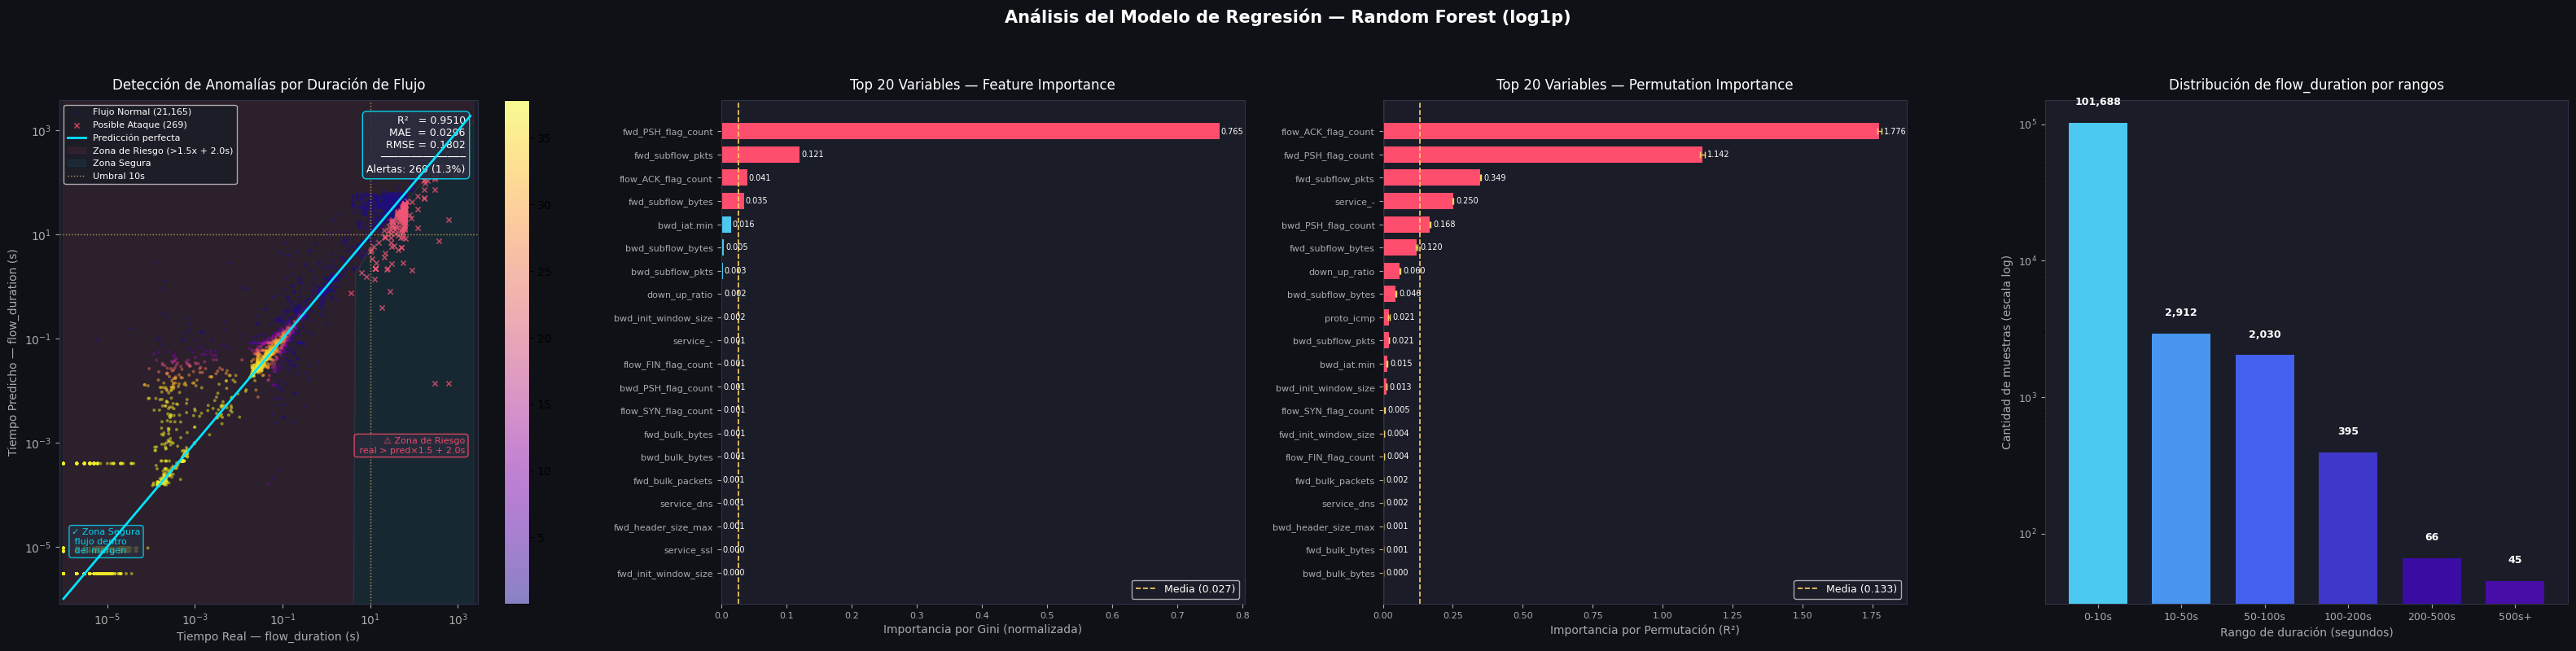

In [23]:
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 4, figsize=(32, 8))
fig.patch.set_facecolor('#0f1117')
for ax in axs:
    ax.set_facecolor('#1a1d27')

fig.suptitle('Análisis del Modelo de Regresión — Random Forest (log1p)',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# ─── Gráfica 1: Detección de Anomalías por Tiempo de Flujo ────────────────

# --- PARÁMETROS DE LA REGLA PREVENTIVA ---
# Si el flujo real supera X veces lo predicho + Y segundos de gracia → sospechoso
MARGEN_TOLERANCIA  = 1.5   # el flujo real puede ser hasta 1.5x lo predicho
SEGUNDOS_DE_GRACIA = 2.0   # margen absoluto adicional en segundos

mask        = (y_test_original_rf > 0) & (predicciones_tiempo_rf > 0)
y_real_mask = y_test_original_rf[mask].values
y_pred_mask = predicciones_tiempo_rf[mask]

# Clasificación de cada punto
tiempo_max_permitido = (y_pred_mask * MARGEN_TOLERANCIA) + SEGUNDOS_DE_GRACIA
es_anomalia          = y_real_mask > tiempo_max_permitido
es_normal            = ~es_anomalia

# Colorear SOLO los normales por densidad
xy_norm   = np.vstack([np.log1p(y_real_mask[es_normal]), np.log1p(y_pred_mask[es_normal])])
density   = gaussian_kde(xy_norm)(xy_norm)
idx_den   = density.argsort()

sc = axs[0].scatter(
    y_real_mask[es_normal][idx_den],
    y_pred_mask[es_normal][idx_den],
    c=density[idx_den], cmap='plasma',
    alpha=0.5, s=8, linewidths=0,
    label=f'Flujo Normal ({es_normal.sum():,})'
)

# Anomalías en rojo con marcador X
axs[0].scatter(
    y_real_mask[es_anomalia],
    y_pred_mask[es_anomalia],
    color='#ff4d6d', alpha=0.7, s=20,
    marker='x', linewidths=1.2,
    label=f'Posible Ataque ({es_anomalia.sum():,})'
)

# Línea de predicción perfecta
min_val = min(y_real_mask.min(), y_pred_mask.min())
max_val = max(y_real_mask.max(), y_pred_mask.max())
axs[0].plot([min_val, max_val], [min_val, max_val],
            color='#00e5ff', linewidth=2,
            label='Predicción perfecta', zorder=5)

# Zona de tolerancia sombreada
# Frontera: real = predicho * margen + gracia  →  predicho = (real - gracia) / margen
x_fill  = np.linspace(min_val, max_val * 1.2, 500)
y_upper = (x_fill - SEGUNDOS_DE_GRACIA) / MARGEN_TOLERANCIA  # límite superior de predicho seguro
y_upper = np.clip(y_upper, 0, None)

axs[0].fill_between(
    x_fill, y_upper, max_val * 2,
    alpha=0.08, color='#ff4d6d',
    label=f'Zona de Riesgo (>{MARGEN_TOLERANCIA}x + {SEGUNDOS_DE_GRACIA}s)'
)
axs[0].fill_between(
    x_fill, 0, y_upper,
    alpha=0.06, color='#00e5ff',
    label='Zona Segura'
)

# Umbral visual de flujos largos
axs[0].axvline(x=10,  color='#ffd166', linestyle=':', linewidth=1, alpha=0.7, label='Umbral 10s')
axs[0].axhline(y=10,  color='#ffd166', linestyle=':', linewidth=1, alpha=0.7)

# Anotaciones de zonas
axs[0].text(
    0.97, 0.30,
    f'⚠ Zona de Riesgo\n real > pred×{MARGEN_TOLERANCIA} + {SEGUNDOS_DE_GRACIA}s',
    transform=axs[0].transAxes, ha='right', fontsize=8,
    color='#ff4d6d', alpha=0.9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#ff4d6d', alpha=0.8)
)
axs[0].text(
    0.03, 0.10,
    '✓ Zona Segura\n flujo dentro\n del margen',
    transform=axs[0].transAxes, ha='left', fontsize=8,
    color='#00e5ff', alpha=0.9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#00e5ff', alpha=0.8)
)

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlim(min_val * 0.8, max_val * 1.5)
axs[0].set_ylim(min_val * 0.8, max_val * 2)
axs[0].set_xlabel('Tiempo Real — flow_duration (s)',    color='#aaaaaa', fontsize=10)
axs[0].set_ylabel('Tiempo Predicho — flow_duration (s)', color='#aaaaaa', fontsize=10)
axs[0].set_title('Detección de Anomalías por Duración de Flujo',
                 color='white', fontsize=12, pad=10)
axs[0].tick_params(colors='#aaaaaa')
axs[0].spines[:].set_color('#2e3347')
axs[0].legend(fontsize=8, facecolor='#1a1d27', labelcolor='white', loc='upper left')

# Cuadro de métricas + resumen de alertas
pct_anomalia = es_anomalia.sum() / len(es_anomalia) * 100
axs[0].text(
    0.97, 0.97,
    (f'R²   = {r2_log:.4f}\n'
     f'MAE  = {mae_log:.4f}\n'
     f'RMSE = {rmse_log:.4f}\n'
     f'──────────────\n'
     f'Alertas: {es_anomalia.sum():,} ({pct_anomalia:.1f}%)'),
    transform=axs[0].transAxes, va='top', ha='right',
    fontsize=9, color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2d3e',
              edgecolor='#00e5ff', alpha=0.9)
)
plt.colorbar(sc, ax=axs[0]).ax.yaxis.label.set_color('white')

# ─── Gráfica 2: Feature Importance ────────────────────────────────────────
importancias_fi = modelo_reg_random_forest.feature_importances_
importancias_fi = importancias_fi / importancias_fi.sum()
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20
media_fi        = importancias_fi.mean()

top_nombres_fi = [nombres[i] for i in indices_fi[:top_n]][::-1]
top_valores_fi = importancias_fi[indices_fi[:top_n]][::-1]
colores_fi     = ['#ff4d6d' if v > media_fi else '#4cc9f0' for v in top_valores_fi]

axs[1].barh(top_nombres_fi, top_valores_fi, color=colores_fi,
            edgecolor='none', height=0.7)
axs[1].axvline(x=media_fi, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_fi:.3f})')
axs[1].set_xlabel('Importancia por Gini (normalizada)', color='#aaaaaa', fontsize=10)
axs[1].set_title(f'Top {top_n} Variables — Feature Importance',
                 color='white', fontsize=12, pad=10)
axs[1].tick_params(colors='#aaaaaa', labelsize=8)
axs[1].spines[:].set_color('#2e3347')
axs[1].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_fi):
    axs[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=7, color='white')

# ─── Gráfica 3: Permutation Importance ────────────────────────────────────
perm_imp = permutation_importance(
    modelo_reg_random_forest, X_test, y_test_log,
    n_repeats=5, random_state=42, n_jobs=1, scoring='r2'
)
importancias_perm = perm_imp.importances_mean
std_vals          = perm_imp.importances_std
indices_perm      = np.argsort(importancias_perm)[::-1]
media_perm        = importancias_perm[importancias_perm > 0].mean() \
                    if (importancias_perm > 0).any() else 0

top_nombres_perm = [nombres[i] for i in indices_perm[:top_n]][::-1]
top_valores_perm = importancias_perm[indices_perm[:top_n]][::-1]
top_std          = std_vals[indices_perm[:top_n]][::-1]
colores_perm     = ['#ff4d6d' if v > 0 else '#4a4e6e' for v in top_valores_perm]

axs[2].barh(top_nombres_perm, top_valores_perm, xerr=top_std,
            color=colores_perm, edgecolor='none', height=0.7,
            error_kw=dict(ecolor='#ffd166', capsize=3, linewidth=1))
axs[2].axvline(x=0, color='white', linewidth=0.8, linestyle='-')
axs[2].axvline(x=media_perm, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_perm:.3f})')
axs[2].set_xlabel('Importancia por Permutación (R²)', color='#aaaaaa', fontsize=10)
axs[2].set_title(f'Top {top_n} Variables — Permutation Importance',
                 color='white', fontsize=12, pad=10)
axs[2].tick_params(colors='#aaaaaa', labelsize=8)
axs[2].spines[:].set_color('#2e3347')
axs[2].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_perm):
    offset = top_std[i] + 0.01
    axs[2].text(v + offset, i, f'{v:.3f}', va='center', fontsize=7, color='white')

# ─── Gráfica 4: Distribución de flow_duration por rangos ──────────────────
rangos    = [0, 10, 50, 100, 200, 500, float('inf')]
etiquetas = ['0-10s', '10-50s', '50-100s', '100-200s', '200-500s', '500s+']
conteo    = pd.cut(y, bins=rangos, labels=etiquetas).value_counts().sort_index()

colores_dist = ['#4cc9f0', '#4895ef', '#4361ee', '#3f37c9', '#3a0ca3', '#480ca8']
bars = axs[3].bar(conteo.index, conteo.values, color=colores_dist,
                  edgecolor='none', width=0.7)
axs[3].set_yscale('log')
axs[3].set_xlabel('Rango de duración (segundos)', color='#aaaaaa', fontsize=10)
axs[3].set_ylabel('Cantidad de muestras (escala log)', color='#aaaaaa', fontsize=10)
axs[3].set_title('Distribución de flow_duration por rangos',
                 color='white', fontsize=12, pad=10)
axs[3].tick_params(colors='#aaaaaa', labelsize=9)
axs[3].spines[:].set_color('#2e3347')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axs[3].text(bar.get_x() + bar.get_width() / 2., h * 1.3,
                    f'{int(h):,}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.show()

Modelo Gradient boosting

In [14]:
# --- MODELO ---
modelo_reg_gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,      # equivalente a max_iter
    random_state=42,
    learning_rate=0.05,
    max_depth=5,
    alpha=0.1,             # equivalente a l2_regularization (usa alpha para regularización)
)

modelo_reg_gradient_boosting.fit(X_train, y_train_log)

# --- PREDECIR ---
pred_log = modelo_reg_gradient_boosting.predict(X_test)

# Se regresa los valores a segundos
predicciones_tiempo_gradient = np.expm1(np.clip(pred_log, -np.inf, 10))
predicciones_tiempo_gradient = np.clip(predicciones_tiempo_gradient, 0, None)
y_test_original = np.expm1(y_test_log)

# --- MÉTRICAS EN ESCALA LOG ---
mae_gradient_log  = mean_absolute_error(y_test_log, pred_log)
mse_gradient_log  = mean_squared_error(y_test_log, pred_log)
rmse_gradient_log = np.sqrt(mse_gradient_log)
r2_gradient_log   = r2_score(y_test_log, pred_log)

# --- MÉTRICAS EN ESCALA REAL ---
mae_gradient  = mean_absolute_error(y_test_original, predicciones_tiempo_gradient)
mse_gradient  = mean_squared_error(y_test_original, predicciones_tiempo_gradient)
rmse_gradient = np.sqrt(mse_gradient)
r2_gradient   = r2_score(y_test_original, predicciones_tiempo_gradient)

print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  : {mae_gradient_log:.6f}")
print(f"  RMSE : {rmse_gradient_log:.6f}")
print(f"  R²   : {r2_gradient_log:.6f}")
print(f"\n  — Escala real (segundos) —")
print(f"  MAE  : {mae_gradient:.6f}")
print(f"  RMSE : {rmse_gradient:.6f}")
print(f"  R²   : {r2_gradient:.6f}")


  — Escala logarítmica (log1p) —
  MAE  : 0.035876
  RMSE : 0.185426
  R²   : 0.948126

  — Escala real (segundos) —
  MAE  : 1.029402
  RMSE : 10.038894
  R²   : 0.673464


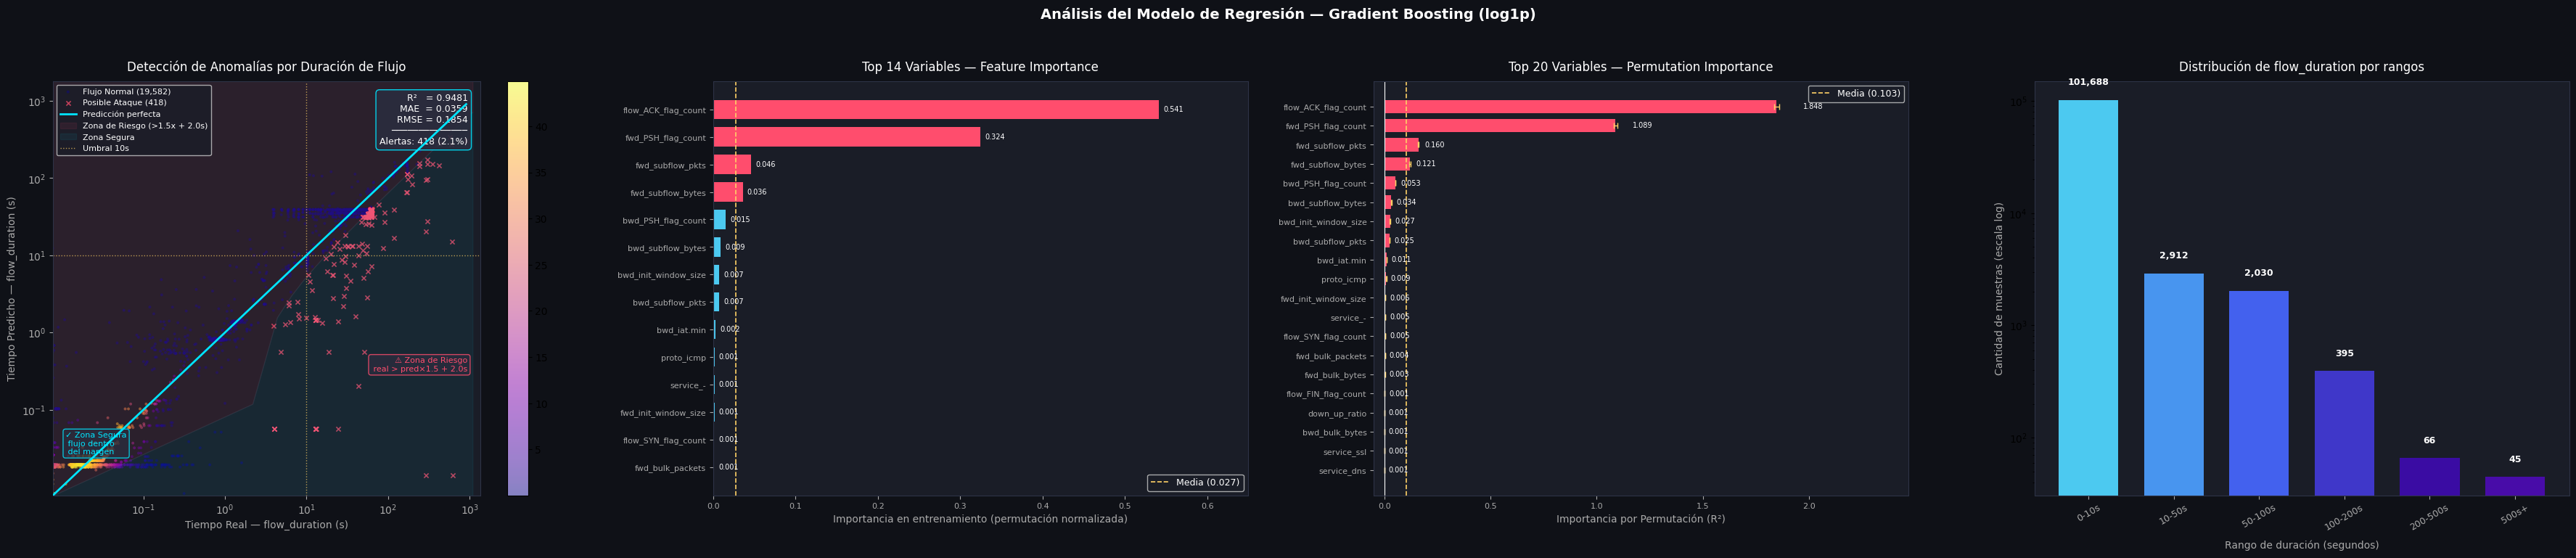

In [29]:
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 4, figsize=(36, 8))
fig.patch.set_facecolor('#0f1117')
for ax in axs:
    ax.set_facecolor('#1a1d27')

fig.suptitle('Análisis del Modelo de Regresión — Gradient Boosting (log1p)',
             fontsize=14, fontweight='bold', color='white')

# --- PARÁMETROS DE LA REGLA PREVENTIVA ---
MARGEN_TOLERANCIA  = 1.5
SEGUNDOS_DE_GRACIA = 2.0

# --- Gráfica 1: Detección de Anomalías por Duración de Flujo ---
mask        = (y_test_original > 0) & (predicciones_tiempo_gradient > 0)
y_real_mask = y_test_original[mask]
y_pred_mask = predicciones_tiempo_gradient[mask]

# Muestrear si hay muchos puntos para que gaussian_kde sea rápido
if len(y_real_mask) > 20000:
    sample_idx  = np.random.choice(len(y_real_mask), 20000, replace=False)
    y_real_mask = y_real_mask.iloc[sample_idx] if hasattr(y_real_mask, 'iloc') else y_real_mask[sample_idx]
    y_pred_mask = y_pred_mask.iloc[sample_idx] if hasattr(y_pred_mask, 'iloc') else y_pred_mask[sample_idx]

# Convertir a numpy para operaciones consistentes
y_real_arr = y_real_mask.values if hasattr(y_real_mask, 'values') else y_real_mask
y_pred_arr = y_pred_mask.values if hasattr(y_pred_mask, 'values') else y_pred_mask

# Clasificación de cada punto
tiempo_max_permitido = (y_pred_arr * MARGEN_TOLERANCIA) + SEGUNDOS_DE_GRACIA
es_anomalia          = y_real_arr > tiempo_max_permitido
es_normal            = ~es_anomalia

# Colorear SOLO los normales por densidad
log_real_n = np.log1p(y_real_arr[es_normal])
log_pred_n = np.log1p(y_pred_arr[es_normal])
xy         = np.vstack([log_real_n, log_pred_n])
density    = gaussian_kde(xy)(xy)
idx_den    = density.argsort()

sc = axs[0].scatter(
    y_real_arr[es_normal][idx_den],
    y_pred_arr[es_normal][idx_den],
    c=density[idx_den], cmap='plasma',
    alpha=0.5, s=8, linewidths=0,
    label=f'Flujo Normal ({es_normal.sum():,})'
)

# Anomalías
axs[0].scatter(
    y_real_arr[es_anomalia],
    y_pred_arr[es_anomalia],
    color='#ff4d6d', alpha=0.7, s=20,
    marker='x', linewidths=1.2,
    label=f'Posible Ataque ({es_anomalia.sum():,})'
)

# Línea de predicción perfecta
min_val = min(y_real_arr.min(), y_pred_arr.min())
max_val = max(y_real_arr.max(), y_pred_arr.max())
axs[0].plot([min_val, max_val], [min_val, max_val],
            color='#00e5ff', linewidth=2,
            label='Predicción perfecta', zorder=5)

# Zona de tolerancia sombreada
x_fill  = np.linspace(min_val, max_val * 1.2, 500)
y_upper = (x_fill - SEGUNDOS_DE_GRACIA) / MARGEN_TOLERANCIA
y_upper = np.clip(y_upper, 0, None)

axs[0].fill_between(
    x_fill, y_upper, max_val * 2,
    alpha=0.08, color='#ff4d6d',
    label=f'Zona de Riesgo (>{MARGEN_TOLERANCIA}x + {SEGUNDOS_DE_GRACIA}s)'
)
axs[0].fill_between(
    x_fill, 0, y_upper,
    alpha=0.06, color='#00e5ff',
    label='Zona Segura'
)

# Umbral visual flujos largos
axs[0].axvline(x=10, color='#ffd166', linestyle=':', linewidth=1, alpha=0.7, label='Umbral 10s')
axs[0].axhline(y=10, color='#ffd166', linestyle=':', linewidth=1, alpha=0.7)

# Anotaciones de zonas
axs[0].text(
    0.97, 0.30,
    f'⚠ Zona de Riesgo\n real > pred×{MARGEN_TOLERANCIA} + {SEGUNDOS_DE_GRACIA}s',
    transform=axs[0].transAxes, ha='right', fontsize=8, color='#ff4d6d',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#ff4d6d', alpha=0.8)
)
axs[0].text(
    0.03, 0.10,
    '✓ Zona Segura\n flujo dentro\n del margen',
    transform=axs[0].transAxes, ha='left', fontsize=8, color='#00e5ff',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#00e5ff', alpha=0.8)
)

axs[0].set_xscale('symlog', linthresh=0.1)
axs[0].set_yscale('symlog', linthresh=0.1)
axs[0].set_xlim(min_val * 0.8, max_val * 1.5)
axs[0].set_ylim(min_val * 0.8, max_val * 2)
axs[0].set_xlabel('Tiempo Real — flow_duration (s)',     color='#aaaaaa', fontsize=10)
axs[0].set_ylabel('Tiempo Predicho — flow_duration (s)', color='#aaaaaa', fontsize=10)
axs[0].set_title('Detección de Anomalías por Duración de Flujo',
                 color='white', fontsize=12, pad=10)
axs[0].tick_params(colors='#aaaaaa')
axs[0].spines[:].set_color('#2e3347')
axs[0].legend(fontsize=8, facecolor='#1a1d27', labelcolor='white', loc='upper left')

# Cuadro de métricas + resumen de alertas
pct_anomalia = es_anomalia.sum() / len(es_anomalia) * 100
axs[0].text(
    0.97, 0.97,
    (f'R²   = {r2_gradient_log:.4f}\n'
     f'MAE  = {mae_gradient_log:.4f}\n'
     f'RMSE = {rmse_gradient_log:.4f}\n'
     f'──────────────\n'
     f'Alertas: {es_anomalia.sum():,} ({pct_anomalia:.1f}%)'),
    transform=axs[0].transAxes, va='top', ha='right',
    fontsize=9, color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2d3e',
              edgecolor='#00e5ff', alpha=0.9)
)
plt.colorbar(sc, ax=axs[0]).ax.yaxis.label.set_color('white')

# --- Gráfica 2: Feature Importance ---
perm_fi = permutation_importance(
    modelo_reg_gradient_boosting, X_train, y_train_log,
    n_repeats=5, random_state=42, n_jobs=1, scoring='r2'
)
importancias_fi = np.clip(perm_fi.importances_mean, 0, None)
importancias_fi = importancias_fi / importancias_fi.sum() if importancias_fi.sum() > 0 else importancias_fi
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20
media_fi        = importancias_fi.mean()

umbral_fi      = 0.001
top_indices_fi = [i for i in indices_fi[:top_n] if importancias_fi[i] > umbral_fi]
top_nombres_fi = [nombres[i] for i in top_indices_fi][::-1]
top_valores_fi = importancias_fi[top_indices_fi][::-1]
colores_fi     = ['#ff4d6d' if v > media_fi else '#4cc9f0' for v in top_valores_fi]

axs[1].barh(top_nombres_fi, top_valores_fi, color=colores_fi, edgecolor='none', height=0.7)
axs[1].axvline(x=media_fi, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_fi:.3f})')
axs[1].set_xlim(0, top_valores_fi.max() * 1.2)
axs[1].set_xlabel('Importancia en entrenamiento (permutación normalizada)',
                  color='#aaaaaa', fontsize=10)
axs[1].set_title(f'Top {len(top_nombres_fi)} Variables — Feature Importance',
                 color='white', fontsize=12, pad=10)
axs[1].tick_params(colors='#aaaaaa', labelsize=8)
axs[1].spines[:].set_color('#2e3347')
axs[1].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_fi):
    if v > umbral_fi:
        axs[1].text(v + top_valores_fi.max() * 0.01, i, f'{v:.3f}',
                    va='center', fontsize=7, color='white')

# --- Gráfica 3: Permutation Importance ---
perm_imp = permutation_importance(
    modelo_reg_gradient_boosting, X_test, y_test_log,
    n_repeats=5, random_state=42, n_jobs=1, scoring='r2'
)
importancias_perm = perm_imp.importances_mean
std_vals          = perm_imp.importances_std
indices_perm      = np.argsort(importancias_perm)[::-1]
media_perm        = importancias_perm[importancias_perm > 0].mean() \
                    if (importancias_perm > 0).any() else 0

top_nombres_perm = [nombres[i] for i in indices_perm[:top_n]][::-1]
top_valores_perm = importancias_perm[indices_perm[:top_n]][::-1]
top_std          = std_vals[indices_perm[:top_n]][::-1]
colores_perm     = ['#ff4d6d' if v > 0 else '#4a4e6e' for v in top_valores_perm]

axs[2].barh(top_nombres_perm, top_valores_perm, xerr=top_std,
            color=colores_perm, edgecolor='none', height=0.7,
            error_kw=dict(ecolor='#ffd166', capsize=3, linewidth=1))
axs[2].axvline(x=0, color='white', linewidth=0.8, linestyle='-')
axs[2].axvline(x=media_perm, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_perm:.3f})')

min_perm = (top_valores_perm - top_std).min()
max_perm = (top_valores_perm + top_std).max()
axs[2].set_xlim(min_perm * 1.3 - 0.05, max_perm * 1.3 + 0.05)
axs[2].set_xlabel('Importancia por Permutación (R²)', color='#aaaaaa', fontsize=10)
axs[2].set_title(f'Top {top_n} Variables — Permutation Importance',
                 color='white', fontsize=12, pad=10)
axs[2].tick_params(colors='#aaaaaa', labelsize=8)
axs[2].spines[:].set_color('#2e3347')
axs[2].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_perm):
    offset = top_std[i] + abs(v) * 0.05 + 0.02
    if v >= 0:
        axs[2].text(v + offset, i, f'{v:.3f}', va='center', ha='left',
                    fontsize=7, color='white')
    else:
        axs[2].text(v - offset, i, f'{v:.3f}', va='center', ha='right',
                    fontsize=7, color='white')

# --- Gráfica 4: Distribución de flow_duration por rangos ---
rangos    = [0, 10, 50, 100, 200, 500, float('inf')]
etiquetas = ['0-10s', '10-50s', '50-100s', '100-200s', '200-500s', '500s+']
conteo    = pd.cut(y, bins=rangos, labels=etiquetas).value_counts().sort_index()

colores_dist = ['#4cc9f0', '#4895ef', '#4361ee', '#3f37c9', '#3a0ca3', '#480ca8']
bars = axs[3].bar(conteo.index, conteo.values, color=colores_dist,
                  edgecolor='none', width=0.7)
axs[3].set_yscale('log')
axs[3].set_xlabel('Rango de duración (segundos)', color='#aaaaaa', fontsize=10, labelpad=8)
axs[3].set_ylabel('Cantidad de muestras (escala log)', color='#aaaaaa', fontsize=10)
axs[3].set_title('Distribución de flow_duration por rangos',
                 color='white', fontsize=12, pad=10)
axs[3].tick_params(colors='#aaaaaa', labelsize=9, axis='x', rotation=30)
axs[3].spines[:].set_color('#2e3347')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axs[3].text(bar.get_x() + bar.get_width() / 2., h * 1.3,
                    f'{int(h):,}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

plt.tight_layout(pad=2.5, w_pad=3.0)
plt.savefig('analisis_gradient_boosting.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

Modelo LightGBM Regressor

In [16]:
modelo_reg_GBM = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_bin=255,
    min_data_in_leaf=5,
    num_leaves=63
)

modelo_reg_GBM.fit(X_train, y_train_log)

pred_GBM = modelo_reg_GBM.predict(X_test)

pred_GBM_real = np.expm1(np.clip(pred_GBM, -np.inf, 10))
pred_GBM_real = np.clip(pred_GBM_real, 0, None)
y_test_original_GBM = np.expm1(y_test_log)

# --- MÉTRICAS EN ESCALA LOG ---
mae_GBM_log  = mean_absolute_error(y_test_log, pred_GBM)
mse_GBM_log  = mean_squared_error(y_test_log, pred_GBM)
rmse_GBM_log = np.sqrt(mse_GBM_log)
r2_GBM_log   = r2_score(y_test_log, pred_GBM)

# --- MÉTRICAS EN ESCALA REAL ---
mae_GBM  = mean_absolute_error(y_test_original_GBM, pred_GBM_real)
mse_GBM  = mean_squared_error(y_test_original_GBM, pred_GBM_real)
rmse_GBM = np.sqrt(mse_GBM)
r2_GBM   = r2_score(y_test_original_GBM, pred_GBM_real)

print(f"\n  — Escala logarítmica (log1p) —")
print(f"  MAE  : {mae_GBM_log:.6f}")
print(f"  RMSE : {rmse_GBM_log:.6f}")
print(f"  R²   : {r2_GBM_log:.6f}")
print(f"\n  — Escala real (segundos) —")
print(f"  MAE  : {mae_GBM:.6f}")
print(f"  RMSE : {rmse_GBM:.6f}")
print(f"  R²   : {r2_GBM:.6f}")

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2127
[LightGBM] [Info] Number of data points in the train set: 98493, number of used features: 36
[LightGBM] [Info] Start training from score 0.203020
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5

  — Escala logarítmica (log1p) —
  MAE  : 0.030112
  RMSE : 0.174285
  R²   : 0.954172

  — Escala real (segundos) —
  MAE  : 1.000908
  RMSE : 12.861093
  R²   : 0.464061


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5


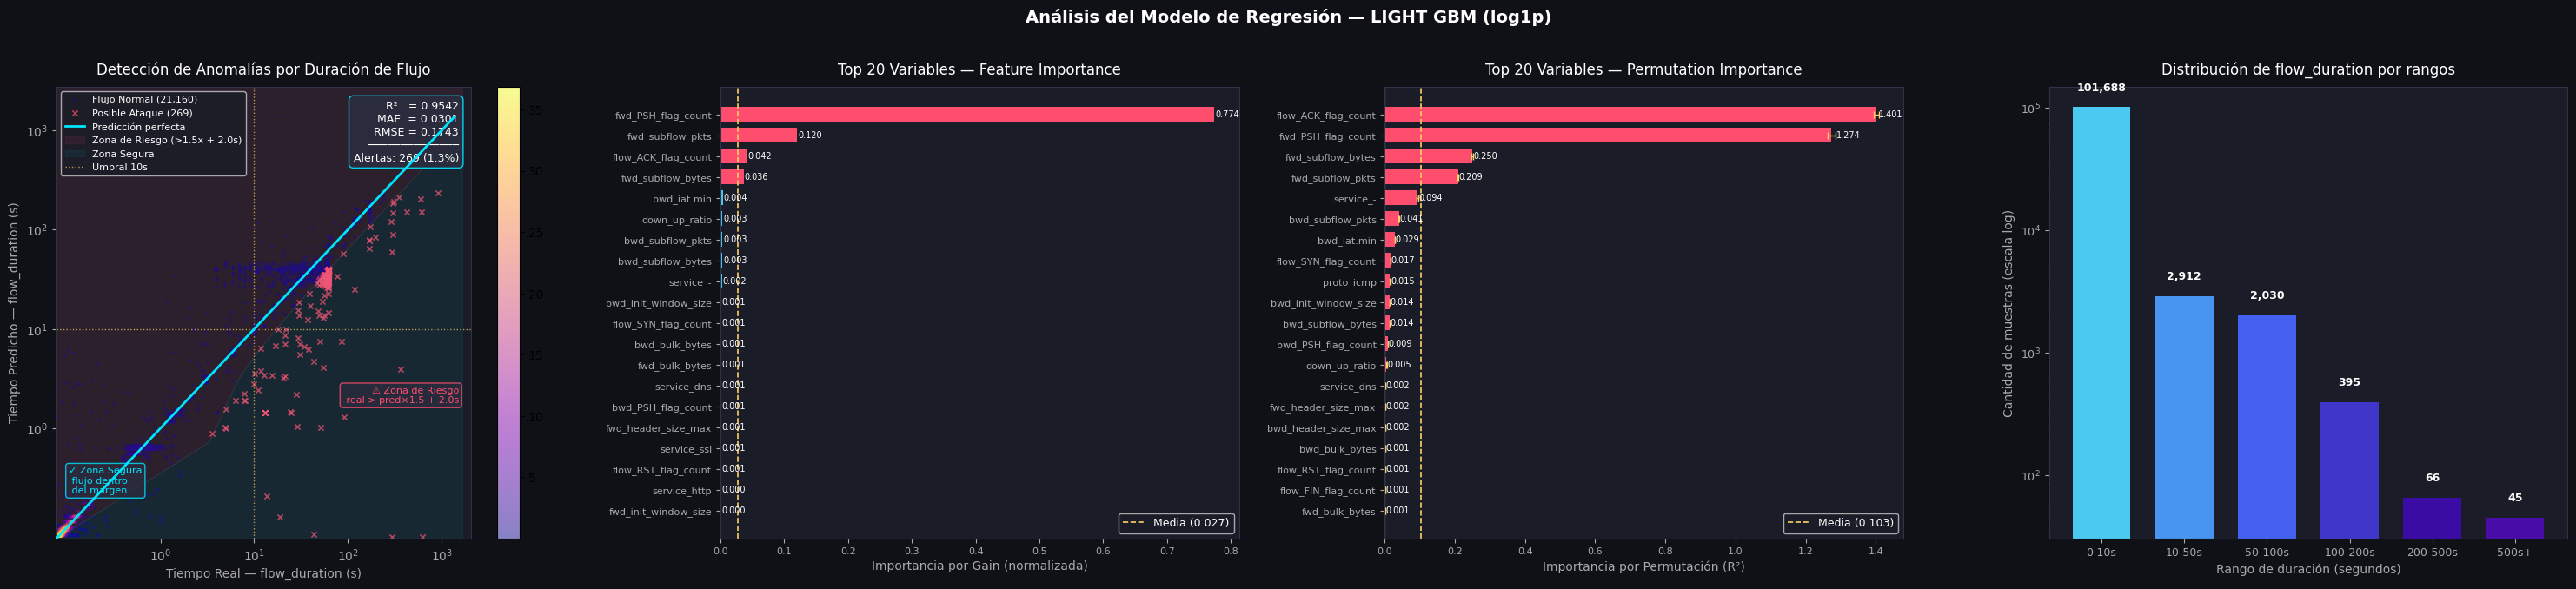

In [28]:
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 4, figsize=(30, 7))
fig.patch.set_facecolor('#0f1117')
for ax in axs:
    ax.set_facecolor('#1a1d27')

fig.suptitle('Análisis del Modelo de Regresión — LIGHT GBM (log1p)',
             fontsize=14, fontweight='bold', color='white')

# --- PARÁMETROS DE LA REGLA PREVENTIVA ---
MARGEN_TOLERANCIA  = 1.5
SEGUNDOS_DE_GRACIA = 2.0

# --- Gráfica 1: Detección de Anomalías por Duración de Flujo ---
pred_GBM_real       = np.expm1(np.clip(pred_GBM, -np.inf, 10))
pred_GBM_real       = np.clip(pred_GBM_real, 0, None)
y_test_original_GBM = np.expm1(y_test_log)

mask       = (y_test_original_GBM > 0) & (pred_GBM_real > 0)
y_real_arr = y_test_original_GBM[mask]
y_pred_arr = pred_GBM_real[mask]

# Clasificación de cada punto
tiempo_max_permitido = (y_pred_arr * MARGEN_TOLERANCIA) + SEGUNDOS_DE_GRACIA
es_anomalia          = y_real_arr > tiempo_max_permitido
es_normal            = ~es_anomalia

# Muestreo solo sobre normales para gaussian_kde
if es_normal.sum() > 20000:
    sample_idx    = np.random.choice(es_normal.sum(), 20000, replace=False)
    # Access .values to get a numpy array for positional indexing
    y_real_sample = y_real_arr[es_normal].values[sample_idx]
    y_pred_sample = y_pred_arr[es_normal][sample_idx]
else:
    y_real_sample = y_real_arr[es_normal]
    y_pred_sample = y_pred_arr[es_normal]

xy      = np.vstack([np.log1p(y_real_sample), np.log1p(y_pred_sample)])
density = gaussian_kde(xy)(xy)
idx_den = density.argsort()

sc = axs[0].scatter(
    y_real_sample[idx_den],
    y_pred_sample[idx_den],
    c=density[idx_den], cmap='plasma',
    alpha=0.5, s=8, linewidths=0,
    label=f'Flujo Normal ({es_normal.sum():,})'
)

# Anomalías
axs[0].scatter(
    y_real_arr[es_anomalia],
    y_pred_arr[es_anomalia],
    color='#ff4d6d', alpha=0.7, s=20,
    marker='x', linewidths=1.2,
    label=f'Posible Ataque ({es_anomalia.sum():,})'
)

# Línea de predicción perfecta
min_val = min(y_real_arr.min(), y_pred_arr.min())
max_val = max(y_real_arr.max(), y_pred_arr.max())
axs[0].plot([min_val, max_val], [min_val, max_val],
            color='#00e5ff', linewidth=2,
            label='Predicción perfecta', zorder=5)

# Zona de tolerancia sombreada
x_fill  = np.linspace(min_val, max_val * 1.2, 500)
y_upper = (x_fill - SEGUNDOS_DE_GRACIA) / MARGEN_TOLERANCIA
y_upper = np.clip(y_upper, 0, None)

axs[0].fill_between(
    x_fill, y_upper, max_val * 2,
    alpha=0.08, color='#ff4d6d',
    label=f'Zona de Riesgo (>{MARGEN_TOLERANCIA}x + {SEGUNDOS_DE_GRACIA}s)'
)
axs[0].fill_between(
    x_fill, 0, y_upper,
    alpha=0.06, color='#00e5ff',
    label='Zona Segura'
)

# Umbral visual flujos largos
axs[0].axvline(x=10, color='#ffd166', linestyle=':', linewidth=1, alpha=0.7, label='Umbral 10s')
axs[0].axhline(y=10, color='#ffd166', linestyle=':', linewidth=1, alpha=0.7)

# Anotaciones de zonas
axs[0].text(
    0.97, 0.30,
    f'⚠ Zona de Riesgo\n real > pred×{MARGEN_TOLERANCIA} + {SEGUNDOS_DE_GRACIA}s',
    transform=axs[0].transAxes, ha='right', fontsize=8, color='#ff4d6d',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#ff4d6d', alpha=0.8)
)
axs[0].text(
    0.03, 0.10,
    '✓ Zona Segura\n flujo dentro\n del margen',
    transform=axs[0].transAxes, ha='left', fontsize=8, color='#00e5ff',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2d3e', edgecolor='#00e5ff', alpha=0.8)
)

axs[0].set_xscale('symlog', linthresh=1.0)
axs[0].set_yscale('symlog', linthresh=1.0)
axs[0].set_xlim(min_val * 0.8, max_val * 1.5)
axs[0].set_ylim(min_val * 0.8, max_val * 2)
axs[0].set_xlabel('Tiempo Real — flow_duration (s)',     color='#aaaaaa', fontsize=10)
axs[0].set_ylabel('Tiempo Predicho — flow_duration (s)', color='#aaaaaa', fontsize=10)
axs[0].set_title('Detección de Anomalías por Duración de Flujo',
                 color='white', fontsize=12, pad=10)
axs[0].tick_params(colors='#aaaaaa')
axs[0].spines[:].set_color('#2e3347')
axs[0].legend(fontsize=8, facecolor='#1a1d27', labelcolor='white', loc='upper left')

# Cuadro de métricas + resumen de alertas
pct_anomalia = es_anomalia.sum() / len(es_anomalia) * 100
axs[0].text(
    0.97, 0.97,
    (f'R²   = {r2_GBM_log:.4f}\n'
     f'MAE  = {mae_GBM_log:.4f}\n'
     f'RMSE = {rmse_GBM_log:.4f}\n'
     f'──────────────\n'
     f'Alertas: {es_anomalia.sum():,} ({pct_anomalia:.1f}%)'),
    transform=axs[0].transAxes, va='top', ha='right',
    fontsize=9, color='white',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2d3e',
              edgecolor='#00e5ff', alpha=0.9)
)
plt.colorbar(sc, ax=axs[0]).ax.yaxis.label.set_color('white')

# --- Gráfica 2: Feature Importances (gain, normalizado) ---
importancias_fi = modelo_reg_GBM.booster_.feature_importance(importance_type='gain')
importancias_fi = importancias_fi / importancias_fi.sum()
nombres         = np.array(X_train.columns)
indices_fi      = np.argsort(importancias_fi)[::-1]
top_n           = 20
media_fi        = importancias_fi.mean()

top_nombres_fi = [nombres[i] for i in indices_fi[:top_n]][::-1]
top_valores_fi = importancias_fi[indices_fi[:top_n]][::-1]
colores_fi     = ['#ff4d6d' if v > media_fi else '#4cc9f0' for v in top_valores_fi]

axs[1].barh(top_nombres_fi, top_valores_fi, color=colores_fi, edgecolor='none', height=0.7)
axs[1].axvline(x=media_fi, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_fi:.3f})')
axs[1].set_xlabel('Importancia por Gain (normalizada)', color='#aaaaaa', fontsize=10)
axs[1].set_title(f'Top {top_n} Variables — Feature Importance',
                 color='white', fontsize=12, pad=10)
axs[1].tick_params(colors='#aaaaaa', labelsize=8)
axs[1].spines[:].set_color('#2e3347')
axs[1].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_fi):
    axs[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=7, color='white')

# --- Gráfica 3: Permutation Importance ---
perm_imp = permutation_importance(
    modelo_reg_GBM, X_test, y_test_log,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='r2'
)
importancias_perm = perm_imp.importances_mean
std_vals          = perm_imp.importances_std
indices_perm      = np.argsort(importancias_perm)[::-1]
media_perm        = importancias_perm[importancias_perm > 0].mean() \
                    if (importancias_perm > 0).any() else 0

top_nombres_perm = [nombres[i] for i in indices_perm[:top_n]][::-1]
top_valores_perm = importancias_perm[indices_perm[:top_n]][::-1]
top_std          = std_vals[indices_perm[:top_n]][::-1]
colores_perm     = ['#ff4d6d' if v > 0 else '#4a4e6e' for v in top_valores_perm]

axs[2].barh(top_nombres_perm, top_valores_perm, xerr=top_std,
            color=colores_perm, edgecolor='none', height=0.7,
            error_kw=dict(ecolor='#ffd166', capsize=3, linewidth=1))
axs[2].axvline(x=0, color='white', linewidth=0.8, linestyle='-')
axs[2].axvline(x=media_perm, color='#ffd166', linestyle='--', linewidth=1.2,
               label=f'Media ({media_perm:.3f})')
axs[2].set_xlabel('Importancia por Permutación (R²)', color='#aaaaaa', fontsize=10)
axs[2].set_title(f'Top {top_n} Variables — Permutation Importance',
                 color='white', fontsize=12, pad=10)
axs[2].tick_params(colors='#aaaaaa', labelsize=8)
axs[2].spines[:].set_color('#2e3347')
axs[2].legend(fontsize=9, facecolor='#1a1d27', labelcolor='white')
for i, v in enumerate(top_valores_perm):
    offset = top_std[i] + 0.001
    axs[2].text(v + offset, i, f'{v:.3f}', va='center', fontsize=7, color='white')

# --- Gráfica 4: Distribución de flow_duration por rangos ---
rangos    = [0, 10, 50, 100, 200, 500, float('inf')]
etiquetas = ['0-10s', '10-50s', '50-100s', '100-200s', '200-500s', '500s+']
conteo    = pd.cut(y, bins=rangos, labels=etiquetas).value_counts().sort_index()

colores_dist = ['#4cc9f0', '#4895ef', '#4361ee', '#3f37c9', '#3a0ca3', '#480ca8']
bars = axs[3].bar(conteo.index, conteo.values, color=colores_dist,
                  edgecolor='none', width=0.7)
axs[3].set_yscale('log')
axs[3].set_xlabel('Rango de duración (segundos)', color='#aaaaaa', fontsize=10)
axs[3].set_ylabel('Cantidad de muestras (escala log)', color='#aaaaaa', fontsize=10)
axs[3].set_title('Distribución de flow_duration por rangos',
                 color='white', fontsize=12, pad=10)
axs[3].tick_params(colors='#aaaaaa', labelsize=9)
axs[3].spines[:].set_color('#2e3347')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axs[3].text(bar.get_x() + bar.get_width() / 2., h * 1.3,
                    f'{int(h):,}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

plt.tight_layout(pad=2.0)
plt.show()

Metodo de validacion

In [18]:
mask = ~np.isnan(y_log)
X_cv     = X[mask]
y_log_cv = y_log[mask]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(modelo_reg_gradient_boosting, X_cv, y_log_cv, cv=cv,
                        scoring={'r2' : 'r2',
                                 'mae': 'neg_mean_absolute_error',
                                 'mse': 'neg_mean_squared_error'},
                        n_jobs=-1)

r2_v   =  cv_res['test_r2']
mae_v  = -cv_res['test_mae']
rmse_v =  np.sqrt(-cv_res['test_mse'])

print("\n" + "="*52)
print("  VALIDACIÓN CRUZADA — HistGradientBoostingRegressor (5 folds)")
print("="*52)
print(f"  {'Fold':<8} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"  {'-'*42}")
for i, (r2, mae, rmse) in enumerate(zip(r2_v, mae_v, rmse_v)):
    print(f"  Fold {i+1}    {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")
print(f"  {'-'*42}")
print(f"  {'Media':<8} {r2_v.mean():>8.4f} {mae_v.mean():>10.4f} {rmse_v.mean():>10.4f}")
print(f"  {'Std':<8} {r2_v.std():>8.4f} {mae_v.std():>10.4f} {rmse_v.std():>10.4f}")
print("="*52)


  VALIDACIÓN CRUZADA — HistGradientBoostingRegressor (5 folds)
  Fold           R²        MAE       RMSE
  ------------------------------------------
  Fold 1      0.9481     0.0359     0.1855
  Fold 2      0.9610     0.0307     0.1580
  Fold 3      0.9639     0.0312     0.1526
  Fold 4      0.9610     0.0324     0.1588
  Fold 5      0.9626     0.0322     0.1586
  ------------------------------------------
  Media      0.9593     0.0325     0.1627
  Std        0.0057     0.0018     0.0116


In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(modelo_reg_GBM, X_cv, y_log_cv, cv=cv,
                        scoring={'r2' : 'r2',
                                 'mae': 'neg_mean_absolute_error',
                                 'mse': 'neg_mean_squared_error'},
                        n_jobs=-1)

r2_v   =  cv_res['test_r2']
mae_v  = -cv_res['test_mae']
rmse_v =  np.sqrt(-cv_res['test_mse'])

print("\n" + "="*52)
print("  VALIDACIÓN CRUZADA — LIGHT GBM (5 folds)")
print("="*52)
print(f"  {'Fold':<8} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"  {'-'*42}")
for i, (r2, mae, rmse) in enumerate(zip(r2_v, mae_v, rmse_v)):
    print(f"  Fold {i+1}    {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")
print(f"  {'-'*42}")
print(f"  {'Media':<8} {r2_v.mean():>8.4f} {mae_v.mean():>10.4f} {rmse_v.mean():>10.4f}")
print(f"  {'Std':<8} {r2_v.std():>8.4f} {mae_v.std():>10.4f} {rmse_v.std():>10.4f}")
print("="*52)


  VALIDACIÓN CRUZADA — LIGHT GBM (5 folds)
  Fold           R²        MAE       RMSE
  ------------------------------------------
  Fold 1      0.9542     0.0301     0.1743
  Fold 2      0.9670     0.0248     0.1454
  Fold 3      0.9668     0.0259     0.1462
  Fold 4      0.9653     0.0268     0.1499
  Fold 5      0.9686     0.0262     0.1453
  ------------------------------------------
  Media      0.9644     0.0268     0.1522
  Std        0.0052     0.0018     0.0111


In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(modelo_reg_random_forest, X_cv, y_log_cv, cv=cv,
                        scoring={'r2':'r2',
                                 'mae':'neg_mean_absolute_error',
                                 'mse':'neg_mean_squared_error'},
                        n_jobs=-1)
r2_v   =  cv_res['test_r2']
mae_v  = -cv_res['test_mae']
rmse_v =  np.sqrt(-cv_res['test_mse'])

print("\n" + "="*52)
print("  VALIDACIÓN CRUZADA — RANDOM FOREST (5 folds)")
print("="*52)
print(f"  {'Fold':<8} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print(f"  {'-'*42}")
for i, (r2, mae, rmse) in enumerate(zip(r2_v, mae_v, rmse_v)):
    print(f"  Fold {i+1}    {r2:>8.4f} {mae:>10.4f} {rmse:>10.4f}")
print(f"  {'-'*42}")
print(f"  {'Media':<8} {r2_v.mean():>8.4f} {mae_v.mean():>10.4f} {rmse_v.mean():>10.4f}")
print(f"  {'Std':<8} {r2_v.std():>8.4f} {mae_v.std():>10.4f} {rmse_v.std():>10.4f}")
print("="*52)


  VALIDACIÓN CRUZADA — RANDOM FOREST (5 folds)
  Fold           R²        MAE       RMSE
  ------------------------------------------
  Fold 1      0.9506     0.0298     0.1809
  Fold 2      0.9636     0.0244     0.1526
  Fold 3      0.9636     0.0252     0.1531
  Fold 4      0.9621     0.0268     0.1566
  Fold 5      0.9647     0.0259     0.1542
  ------------------------------------------
  Media      0.9609     0.0264     0.1595
  Std        0.0052     0.0019     0.0108


In [21]:
# --- TABLA COMPARATIVA FINAL DE TODOS LOS MODELOS ---
import pandas as pd
from IPython.display import display

resultados_comparativos = pd.DataFrame({
    'Modelo': [
        'Red Neuronal (MLP)',
        'Random Forest',
        'Gradient Boosting',
        'LightGBM'
    ],
    'R² (Log1p)': [
        r2_log_mlp,
        r2_log,
        r2_gradient_log,
        r2_GBM_log
    ],
    'MAE (Segundos Reales)': [
        mae_real_mlp,
        mae_real,
        mae_gradient,
        mae_GBM
    ],
    'RMSE (Segundos Reales)': [
        rmse_real_mlp,
        rmse_real,
        rmse_gradient,
        rmse_GBM
    ]
})

resultados_comparativos = resultados_comparativos.sort_values(
    by='R² (Log1p)', ascending=False
).reset_index(drop=True)

def destacar_mejores(s):
    if s.name == 'R² (Log1p)':
        is_best = s == s.max()
    elif s.name in ['MAE (Segundos Reales)', 'RMSE (Segundos Reales)']:
        is_best = s == s.min()
    else:
        is_best = [False] * len(s)
    return ['background-color: #1D9E75; color: white; font-weight: bold' if v else '' for v in is_best]

tabla_final = resultados_comparativos.style.apply(destacar_mejores)\
    .format({
        'R² (Log1p)':             '{:.4f}',
        'MAE (Segundos Reales)':  '{:.4f}s',
        'RMSE (Segundos Reales)': '{:.4f}s'
    })\
    .set_caption("RESUMEN DE RENDIMIENTO: PREDICCIÓN DE FLUJOS IoT")

display(tabla_final)

,Modelo,R² (Log1p),MAE (Segundos Reales),RMSE (Segundos Reales)
0,LightGBM,0.9542,1.0009s,12.8611s
1,Random Forest,0.9510,1.0467s,15.8292s
2,Gradient Boosting,0.9481,1.0294s,10.0389s
3,Red Neuronal (MLP),0.9480,1.0833s,10.7140s
